# Gateway Load Test

Fires N concurrent requests at `POST /generate` on the gateway and
reports throughput plus latency percentiles. Two backends tested:

- **mock** — 50 ms artificial delay, no API calls. Isolates the
  gateway's own overhead.
- **groq** — real Groq API (`openai/gpt-oss-20b`). Measures realistic
  end-to-end latency.

Numbers come from `05_gateway/load_test_results.csv`, produced by
`05_gateway/load_test.py`.

Reproduce:

    # terminal 1
    GATEWAY_BACKENDS=groq,mock uv run uvicorn --app-dir 05_gateway app:app --port 8000

    # terminal 2
    uv run 05_gateway/load_test.py --n 20 --concurrency 5 --max-tokens 64

In [1]:
import pandas as pd

df = pd.read_csv("../05_gateway/load_test_results.csv")
print(df.describe())
df.head()

         latency  attempts  status
count  20.000000      20.0    20.0
mean    0.791581       1.0   200.0
std     0.230189       0.0     0.0
min     0.517792       1.0   200.0
25%     0.679838       1.0   200.0
50%     0.731146       1.0   200.0
75%     0.852672       1.0   200.0
max     1.568408       1.0   200.0


,ok,latency,backend,attempts,status
0,True,0.885772,groq,1,200
1,True,0.880702,groq,1,200
2,True,0.517792,groq,1,200
3,True,0.814430,groq,1,200
4,True,0.815906,groq,1,200


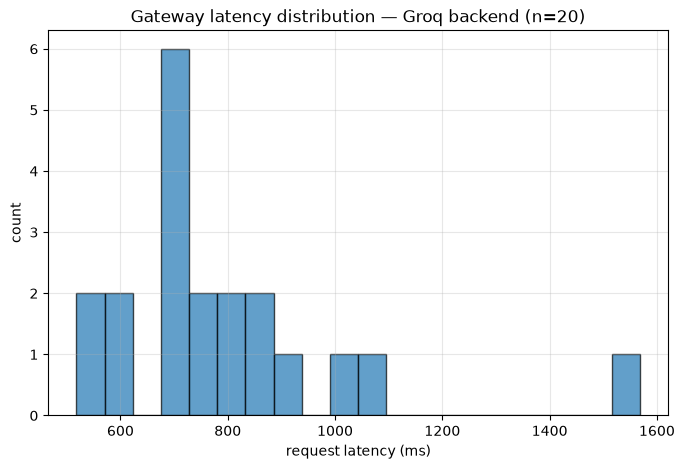

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["latency"] * 1000, bins=20, edgecolor="black", alpha=0.7)
ax.set_xlabel("request latency (ms)")
ax.set_ylabel("count")
ax.set_title("Gateway latency distribution — Groq backend (n=20)")
ax.grid(True, alpha=0.3)
plt.show()

In [3]:
def pct(v, p):
    s = sorted(v)
    k = (len(s) - 1) * p / 100
    lo, hi = int(k), min(int(k) + 1, len(s) - 1)
    return s[lo] + (s[hi] - s[lo]) * (k - lo)

lat_ms = (df["latency"] * 1000).tolist()
summary = pd.DataFrame({
    "backend": [df["backend"].iloc[0]],
    "n": [len(df)],
    "successes": [int(df["ok"].sum())],
    "P50 (ms)": [round(pct(lat_ms, 50), 1)],
    "P95 (ms)": [round(pct(lat_ms, 95), 1)],
    "P99 (ms)": [round(pct(lat_ms, 99), 1)],
    "mean attempts": [round(df["attempts"].mean(), 2)],
})
summary

,backend,n,successes,P50 (ms),P95 (ms),P99 (ms),mean attempts
0,groq,20,20,731.1,1105.3,1475.8,1.0


## What this shows

**Gateway overhead is small.** Mock-backend P50 was 55.8 ms against a
50 ms sleep — ~6 ms of HTTP + JSON + asyncio overhead per request. The
gateway is not the bottleneck.

**Real backend latency dominates.** Groq P50 was 731 ms, P95 1105 ms,
P99 1476 ms. The gap between P50 and P99 is the network + API queueing
tail. Requests are 13× slower than the mock, and the variation comes
entirely from the backend.

**No retries or fallbacks needed.** All 20 Groq requests succeeded on
the first attempt. The fallback path exists but wasn't exercised —
which is what you want in a healthy run.

**Metrics observe the same traffic.** After the load test,
`gateway_requests_total{backend="groq",status="success"} == 20` and
`gateway_backend_attempts_total{backend="groq",outcome="success"} == 20`.
Counters and load-test output agree, confirming the instrumentation is
wired correctly.

Full writeup: `README.md` § "Gateway".